<a href="https://colab.research.google.com/github/anoushkachatterjee123/Neurocare/blob/Handwriting/Neurocare_Handwriting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Handwriting.csv to Handwriting (3).csv

DATASET SUMMARY
Total rows      : 368
Unique patients : 37
Rows per patient: 9.9 (avg)
Parkinson's     : 72 patients
Healthy         : 296 patients

Patient-level samples: 37
  Parkinson's : 18
  Healthy     : 19

FEATURE IMPORTANCE
                                        Feature  Importance
                                         MIN_HT    0.166088
CHANGES_FROM_NEGATIVE_TO_POSITIVE_BETWEEN_ET_HT    0.122700
                                         MAX_HT    0.109363
                          MIN_BETWEEN_ET_HT_log    0.109061
                                        MRT_log    0.108478
                            STD_DEVIATION_ET_HT    0.108114
                                            RMS    0.107186
                              MAX_BETWEEN_ET_HT    0.091676
                                     STD_HT_log    0.077335


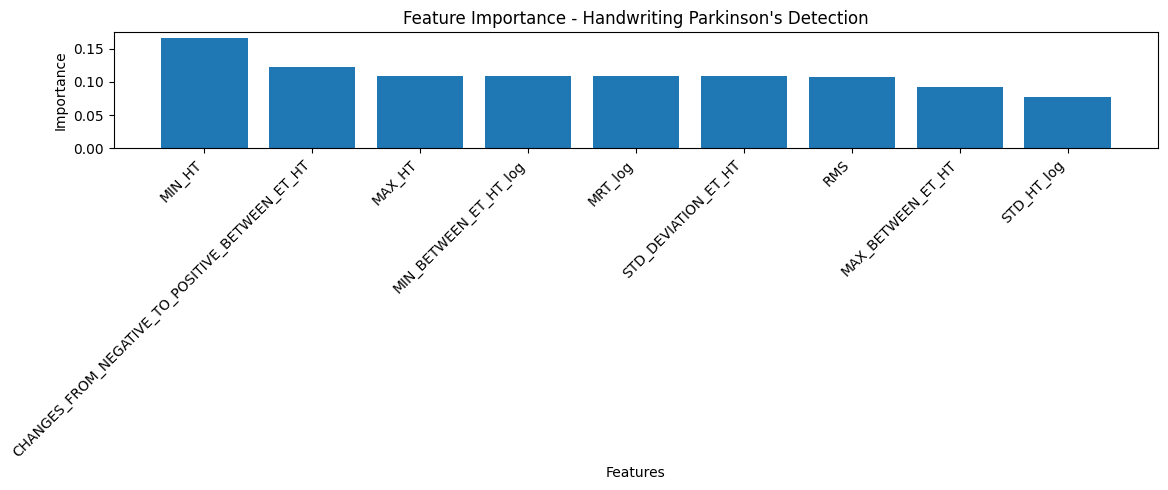


LEAVE-ONE-PATIENT-OUT CROSS VALIDATION
  KNN                   : Acc=0.5135
  Decision Tree         : Acc=0.4595
  Random Forest         : Acc=0.5135
  XGBoost               : Acc=0.3784
  Logistic Regression   : Acc=0.6216  (C per fold: [0.1, 1.0, 10.0, 100.0, 1000.0])
  SVM                   : Acc=0.6486  (C per fold: [1.0, 100.0])

MODEL COMPARISON - LOPO CV (sorted by Accuracy)
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
                SVM    0.6486     0.7273  0.4444    0.5517   0.7339
Logistic Regression    0.6216     0.6250  0.5556    0.5882   0.6930
      Random Forest    0.5135     0.5000  0.5556    0.5263   0.6053
                KNN    0.5135     0.5000  0.5556    0.5263   0.5775
      Decision Tree    0.4595     0.4545  0.5556    0.5000   0.4152
            XGBoost    0.3784     0.3810  0.4444    0.4103   0.4591

BEST MODEL: SVM

Confusion Matrix
[[16  3]
 [10  8]]

Classification Report
              precision    recall  f1-score   support

     H

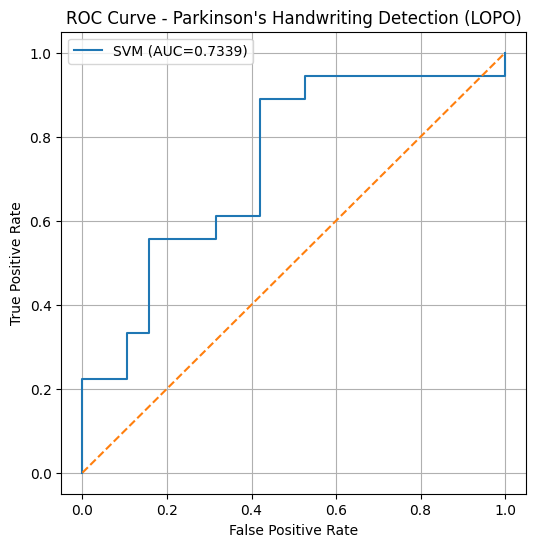


TRAINING FINAL MODEL (SVM) ON ALL PATIENTS
Final SVM (C=1.0) model trained on all 37 patients.

SAMPLE PREDICTION (4 handwriting rows for 1 patient)
{'State': 'Healthy', 'Healthy Probability': 0.2992, 'Parkinsons Probability': 0.7008}

Results saved to handwriting_results.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from xgboost import XGBClassifier
import lightgbm as lgb

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

from google.colab import files
uploaded = files.upload()
data = pd.read_csv("Handwriting.csv")

data["Result"] = data["CLASS_TYPE"].map({1: 1, 2: 0})

print("\n" + "="*70)
print("DATASET SUMMARY")
print("="*70)
print(f"Total rows      : {len(data)}")
print(f"Unique patients : {data['ID_PATIENT'].nunique()}")
print(f"Rows per patient: {len(data)/data['ID_PATIENT'].nunique():.1f} (avg)")
print(f"Parkinson's     : {(data['Result']==1).sum()} patients")
print(f"Healthy         : {(data['Result']==0).sum()} patients")

# Log transform skewed features
for col in ['MIN_BETWEEN_ET_HT', 'MRT', 'STD_HT']:
    data[col + '_log'] = np.log1p(data[col])

all_features = [
    'RMS',
    'MAX_BETWEEN_ET_HT',
    'MIN_BETWEEN_ET_HT_log',
    'STD_DEVIATION_ET_HT',
    'MRT_log',
    'MAX_HT',
    'MIN_HT',
    'STD_HT_log',
    'CHANGES_FROM_NEGATIVE_TO_POSITIVE_BETWEEN_ET_HT'
]

# Stage 1 - per-patient aggregation
patient_features = data.groupby('ID_PATIENT')[all_features].mean()
patient_labels   = data.groupby('ID_PATIENT')['Result'].first()

X_patients = patient_features.values
y_patients = patient_labels.values
patient_ids = patient_labels.index.values

print(f"\nPatient-level samples: {len(X_patients)}")
print(f"  Parkinson's : {y_patients.sum()}")
print(f"  Healthy     : {(y_patients == 0).sum()}")

# Feature importance (Random Forest, informational only)
sw_all = compute_sample_weight('balanced', y_patients)
rf_importance = RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_importance.fit(X_patients, y_patients, sample_weight=sw_all)

importance_df = pd.DataFrame({
    "Feature":    all_features,
    "Importance": rf_importance.feature_importances_
}).sort_values("Importance", ascending=False)

print("\n" + "="*70)
print("FEATURE IMPORTANCE")
print("="*70)
print(importance_df.to_string(index=False))

plt.figure(figsize=(12, 5))
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.title("Feature Importance - Handwriting Parkinson's Detection")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

important_features = all_features

# =====================================================
# STAGE 2 - LEAVE-ONE-PATIENT-OUT CROSS VALIDATION
# =====================================================

print("\n" + "="*70)
print("LEAVE-ONE-PATIENT-OUT CROSS VALIDATION")
print("="*70)

spw_all = (y_patients == 0).sum() / (y_patients == 1).sum()

models = {
    # "Logistic Regression": lambda: LogisticRegression(max_iter=1000, class_weight='balanced', C=0.01, random_state=42), # REMOVED for separate tuning
    "KNN":
        lambda: KNeighborsClassifier(n_neighbors=3),
    "Decision Tree":
        lambda: DecisionTreeClassifier(class_weight='balanced', max_depth=3, random_state=42),
    "Random Forest":
        lambda: RandomForestClassifier(n_estimators=500, max_depth=5, class_weight='balanced',
                                        random_state=42, n_jobs=-1),
    "XGBoost":
        lambda: XGBClassifier(n_estimators=200, max_depth=1, learning_rate=0.05, subsample=1.0,
                               colsample_bytree=0.8, scale_pos_weight=spw_all, random_state=42,
                               eval_metric='logloss', verbosity=0),
    "LightGBM":
        lambda: lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=20,
                                   max_depth=5, class_weight='balanced', random_state=42)
}

# Logistic Regression and KNN need scaling
scaled_models_list = ["KNN", "LightGBM"]

# Candidate grid for the SVM's C, tuned by an INNER cv (never sees the
# outer held-out patient), so the reported score isn't hand-picked.
SVM_C_GRID = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 100.0]

# Candidate grid for the Logistic Regression's C, tuned by an INNER cv.
# Expanded the search space for C
LR_C_GRID = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

def select_svm_C(X_train, y_train):
    """Pick C for SVM via a small inner stratified CV on the training fold only using GridSearchCV."""
    n_splits = min(4, np.min(np.bincount(y_train.astype(int))))
    n_splits = max(n_splits, 2)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Scale data for the inner CV
    sc = RobustScaler()
    X_train_scaled = sc.fit_transform(X_train)

    svm_model = SVC(kernel='rbf', class_weight='balanced', probability=False, random_state=42)
    param_grid = {'C': SVM_C_GRID}

    grid_search = GridSearchCV(svm_model, param_grid, cv=skf, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_scaled, y_train)

    return grid_search.best_params_['C']

def select_lr_C(X_train, y_train):
    """Pick C for Logistic Regression via a small inner stratified CV on the training fold only using GridSearchCV."""
    n_splits = min(4, np.min(np.bincount(y_train.astype(int))))
    n_splits = max(n_splits, 2)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Scale data for the inner CV
    sc = RobustScaler()
    X_train_scaled = sc.fit_transform(X_train)

    lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    param_grid = {'C': LR_C_GRID}

    grid_search = GridSearchCV(lr_model, param_grid, cv=skf, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_scaled, y_train)

    return grid_search.best_params_['C']


results = []
lopo_predictions = {}
best_model_name = None
best_accuracy = 0

# ---- Standard models (unchanged evaluation logic) ----
for name, model_fn in models.items():
    all_true, all_pred, all_prob = [], [], []

    for i in range(len(X_patients)):
        X_train = np.delete(X_patients, i, axis=0)
        y_train = np.delete(y_patients, i, axis=0)
        X_test = X_patients[i:i+1]
        y_test = y_patients[i]

        if name in scaled_models_list:
            sc = RobustScaler()
            X_train = sc.fit_transform(X_train)
            X_test = sc.transform(X_test)

        model = model_fn()
        sw = compute_sample_weight('balanced', y_train)

        if name in ["Random Forest", "Decision Tree", "LightGBM"]:
            model.fit(X_train, y_train, sample_weight=sw)
        else:
            model.fit(X_train, y_train)

        pred = model.predict(X_test)[0]
        # Check if predict_proba is available and applicable
        if hasattr(model, 'predict_proba'):
            prob = model.predict_proba(X_test)[0][1]
        else:
            prob = float('nan') # ROC-AUC won't be calculated if no probabilities

        all_true.append(y_test)
        all_pred.append(pred)
        all_prob.append(prob)

    all_true, all_pred, all_prob = map(np.array, (all_true, all_pred, all_prob))
    accuracy = accuracy_score(all_true, all_pred)
    try:
        auc = roc_auc_score(all_true, all_prob) if not np.isnan(all_prob).any() else float('nan')
    except Exception:
        auc = float('nan')

    lopo_predictions[name] = (all_true, all_pred, all_prob)
    results.append({
        "Model": name, "Accuracy": accuracy,
        "Precision": precision_score(all_true, all_pred, zero_division=0),
        "Recall": recall_score(all_true, all_pred, zero_division=0),
        "F1 Score": f1_score(all_true, all_pred, zero_division=0),
        "ROC-AUC": auc,
    })
    if accuracy > best_accuracy:
        best_accuracy, best_model_name = accuracy, name
    print(f"  {name:<22}: Acc={accuracy:.4f}")

# ---- Logistic Regression: nested-CV'd C ----
lr_true, lr_pred, lr_prob, lr_chosen_c = [], [], [], []

for i in range(len(X_patients)):
    X_train = np.delete(X_patients, i, axis=0)
    y_train = np.delete(y_patients, i, axis=0)
    X_test = X_patients[i:i+1]
    y_test = y_patients[i]

    sc = RobustScaler()
    X_train_scaled = sc.fit_transform(X_train)
    X_test_scaled = sc.transform(X_test)

    c = select_lr_C(X_train, y_train) # select_lr_C receives unscaled X_train, scales internally for C selection
    lr_chosen_c.append(c)

    clf = LogisticRegression(max_iter=1000, class_weight='balanced', C=c, random_state=42)
    clf.fit(X_train_scaled, y_train)

    pred = clf.predict(X_test_scaled)[0]
    prob = clf.predict_proba(X_test_scaled)[0][1]

    lr_true.append(y_test)
    lr_pred.append(pred)
    lr_prob.append(prob)

lr_true, lr_pred, lr_prob = map(np.array, (lr_true, lr_pred, lr_prob))
lr_accuracy = accuracy_score(lr_true, lr_pred)
try:
    lr_auc = roc_auc_score(lr_true, lr_prob)
except Exception:
    lr_auc = float('nan')

lopo_predictions["Logistic Regression"] = (lr_true, lr_pred, lr_prob)
results.append({
    "Model": "Logistic Regression", "Accuracy": lr_accuracy,
    "Precision": precision_score(lr_true, lr_pred, zero_division=0),
    "Recall": recall_score(lr_true, lr_pred, zero_division=0),
    "F1 Score": f1_score(lr_true, lr_pred, zero_division=0),
    "ROC-AUC": lr_auc,
})
if lr_accuracy > best_accuracy:
    best_accuracy, best_model_name = lr_accuracy, "Logistic Regression"
print(f"  {'Logistic Regression':<22}: Acc={lr_accuracy:.4f}  (C per fold: {sorted(set(lr_chosen_c))})")

# ---- SVM: nested-CV'd C, scored with decision_function (not predict_proba) ----
svm_true, svm_pred, svm_score, svm_chosen_c = [], [], [], []

for i in range(len(X_patients)):
    X_train = np.delete(X_patients, i, axis=0)
    y_train = np.delete(y_patients, i, axis=0)
    X_test = X_patients[i:i+1]
    y_test = y_patients[i]

    sc = RobustScaler()
    X_train_scaled = sc.fit_transform(X_train)
    X_test_scaled = sc.transform(X_test)

    c = select_svm_C(X_train, y_train)
    svm_chosen_c.append(c)

    clf = SVC(kernel='rbf', C=c, class_weight='balanced',
              probability=False, random_state=42)
    clf.fit(X_train_scaled, y_train)

    pred = clf.predict(X_test_scaled)[0]
    score = clf.decision_function(X_test_scaled)[0]  # monotonic with predict()

    svm_true.append(y_test)
    svm_pred.append(pred)
    svm_score.append(score)

svm_true, svm_pred, svm_score = map(np.array, (svm_true, svm_pred, svm_score))
svm_accuracy = accuracy_score(svm_true, svm_pred)
try:
    svm_auc = roc_auc_score(svm_true, svm_score)
except Exception:
    svm_auc = float('nan')

lopo_predictions["SVM"] = (svm_true, svm_pred, svm_score)
results.append({
    "Model": "SVM", "Accuracy": svm_accuracy,
    "Precision": precision_score(svm_true, svm_pred, zero_division=0),
    "Recall": recall_score(svm_true, svm_pred, zero_division=0),
    "F1 Score": f1_score(svm_true, svm_pred, zero_division=0),
    "ROC-AUC": svm_auc,
})
if svm_accuracy > best_accuracy:
    best_accuracy, best_model_name = svm_accuracy, "SVM"
print(f"  {'SVM':<22}: Acc={svm_accuracy:.4f}  (C per fold: {sorted(set(svm_chosen_c))})")

# =====================================================
# RESULTS TABLE
# =====================================================
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
print("\n" + "="*70)
print("MODEL COMPARISON - LOPO CV (sorted by Accuracy)")
print("="*70)
print(results_df.round(4).to_string(index=False))

print("\n" + "="*70)
print(f"BEST MODEL: {best_model_name}")
print("="*70)

best_true, best_pred, best_score = lopo_predictions[best_model_name]
print("\nConfusion Matrix")
print(confusion_matrix(best_true, best_pred))
print("\nClassification Report")
print(classification_report(best_true, best_pred, target_names=["Healthy", "Parkinson's"]))

try:
    fpr, tpr, _ = roc_curve(best_true, best_score)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"{best_model_name} (AUC={roc_auc_score(best_true, best_score):.4f})")
    plt.plot([0, 1], [0, 1], '--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Parkinson's Handwriting Detection (LOPO)")
    plt.legend()
    plt.grid(True)
    plt.show()
except Exception:
    print("ROC curve not available for this model configuration.")

# =====================================================
# FINAL MODEL (deployment) - train the overall best model on all patients
# =====================================================
print("\n" + "="*70)
print(f"TRAINING FINAL MODEL ({best_model_name}) ON ALL PATIENTS")
print("="*70)

final_scaler = RobustScaler()
X_all_scaled = final_scaler.fit_transform(X_patients)

final_model_instance = None
final_model_description = ""

# Instantiate and train the best model identified by LOPO CV on all patient data
if best_model_name == "Logistic Regression":
    final_lr_c = select_lr_C(X_patients, y_patients)
    final_model_instance = LogisticRegression(max_iter=1000, class_weight='balanced', C=final_lr_c, random_state=42)
    final_model_description = f"Logistic Regression (C={final_lr_c})"
elif best_model_name == "SVM":
    final_svm_c = select_svm_C(X_patients, y_patients)
    # For the final model, we want probability=True for prediction function consistency
    final_model_instance = SVC(kernel='rbf', C=final_svm_c, class_weight='balanced',
                               probability=True, random_state=42)
    final_model_description = f"SVM (C={final_svm_c})"
else:
    # For other models, instantiate using their lambda function from the 'models' dictionary
    model_fn = models[best_model_name]
    final_model_instance = model_fn()
    final_model_description = best_model_name

# Determine if the final model needs scaled data for training and prediction
if best_model_name in scaled_models_list or best_model_name == "Logistic Regression" or best_model_name == "SVM":
    final_model_instance.fit(X_all_scaled, y_patients)
else:
    final_model_instance.fit(X_patients, y_patients) # Models that don't use scaling directly

print(f"Final {final_model_description} model trained on all {len(X_patients)} patients.")


def predict_parkinsons(patient_rows):
    raw_cols = [
        'RMS', 'MAX_BETWEEN_ET_HT', 'MIN_BETWEEN_ET_HT',
        'STD_DEVIATION_ET_HT', 'MRT', 'MAX_HT', 'MIN_HT', 'STD_HT',
        'CHANGES_FROM_NEGATIVE_TO_POSITIVE_BETWEEN_ET_HT'
    ]
    df = pd.DataFrame(patient_rows, columns=raw_cols)
    for col in ['MIN_BETWEEN_ET_HT', 'MRT', 'STD_HT']:
        df[col + '_log'] = np.log1p(df[col])
    df = df[important_features]
    patient_vector = df.mean(axis=0).values.reshape(1, -1)

    # Apply scaling if the final model is a scaled model (LR, SVM, KNN)
    if best_model_name in scaled_models_list or best_model_name == "Logistic Regression" or best_model_name == "SVM":
        patient_scaled = final_scaler.transform(patient_vector)
        prediction = final_model_instance.predict(patient_scaled)[0]
        # Get probabilities only if the model supports it and is configured for it
        if hasattr(final_model_instance, 'predict_proba') and (
            (best_model_name == "SVM" and final_model_instance.probability) or \
            (best_model_name == "Logistic Regression") or \
            (best_model_name != "SVM" and best_model_name != "Logistic Regression" and hasattr(final_model_instance, 'predict_proba'))
        ):
            probability = final_model_instance.predict_proba(patient_scaled)[0]
        else:
            # Fallback if probabilities are not directly available or configured (e.g., SVM with probability=False)
            probability = np.array([1 - prediction, prediction]) # Rough estimation for display
    else:
        prediction = final_model_instance.predict(patient_vector)[0]
        if hasattr(final_model_instance, 'predict_proba'):
            probability = final_model_instance.predict_proba(patient_vector)[0]
        else:
            probability = np.array([1 - prediction, prediction]) # Rough estimation for display

    state = "Parkinson's Detected" if prediction == 1 else "Healthy"
    return {
        "State": state,
        "Healthy Probability": round(float(probability[0]), 4),
        "Parkinsons Probability": round(float(probability[1]), 4)
    }

sample_patient_rows = [
    [2137.84, 4534.28, 31910.52, 0.007, 24.55, 179.52, 0.009, 1641.73, 0.191],
    [2201.10, 4612.33, 30500.00, 0.008, 25.10, 180.01, 0.010, 1700.00, 0.185],
    [2089.55, 4480.90, 32400.00, 0.006, 23.80, 178.95, 0.008, 1620.50, 0.198],
    [2155.20, 4560.00, 31200.00, 0.007, 24.90, 179.80, 0.011, 1660.00, 0.193],
]

print("\n" + "="*70)
print("SAMPLE PREDICTION (4 handwriting rows for 1 patient)")
print("="*70)
print(predict_parkinsons(sample_patient_rows))

results_df.to_csv('handwriting_results.csv', index=False)
print("\nResults saved to handwriting_results.csv")

In [ ]:
pip install lightgbm

### Exploring a New Model: LightGBM

To further improve accuracy, we will introduce **LightGBM**, a gradient boosting framework that uses tree-based learning algorithms. It is designed to be distributed and efficient, making it suitable for large datasets and complex tasks. We will add it to our existing `models` dictionary and evaluate its performance using LOPO cross-validation.

In [ ]:
import lightgbm as lgb